# Mock stream generator
## Building and testing the restricted N-body algorithm

### Evolving CloudsMW test

In [1]:
using TestEnv
TestEnv.activate()

"/tmp/jl_PIGscp/Project.toml"

In [2]:
using Dynamigal
using Test
using PythonCall
using CairoMakie
using BenchmarkTools
using DataFrames
using CSV

#### Integrating MW + Large cloud + Small cloud without friction, as MacroParticleSystem and as CloudsMW.

In [131]:
t₁ = 0.0
t₂ = -3.0
t_range = (t₁, t₂)
Δt = -0.001
pot_mw = MilkyWayPriceWhelan2017()
pot_large = NFW(m=8.78206139e+10, a=10.3264466)
pot_small = NFW(m=1.22160828e+10, a=8.26115728)
x_large = [-1.045752, -40.616098, -27.536917]
v_large = adimensional([-53.95, -228.51, 217.55]*𝕦.ν)
x_small = [15.099058, -38.088847, -44.195933]
v_small = adimensional([18.6, -183.86, 173.94]*𝕦.ν)
mp_mw = MacroParticle(pot_mw, zeros(3), zeros(3))
mp_large = MacroParticle(pot_large, x_large, v_large)
mp_small = MacroParticle(pot_small, x_small, v_small)
mps = MacroParticleSystem(mp_mw, mp_large, mp_small)
sol = evolve(mps, t_range, Vern7(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))


🎲 Evolving a MPS system without friction, GenSystTrait


3-element Vector{Orbit}:
 Orbit{Float64, Float64, Float64}([0.0, -0.001, -0.002, -0.003, -0.004, -0.005, -0.006, -0.007, -0.008, -0.009  …  -2.991, -2.992, -2.993, -2.994, -2.995, -2.996, -2.997, -2.998, -2.999, -3.0], [0.0 7.551659912011005e-7 … 25.719200483020632 25.72288218096766; 0.0 -6.851201485499776e-5 … 121.89617630201336 121.95821276969143; 0.0 -4.951264645030342e-5 … -127.87453962686416 -127.8619378339946], [0.0 -0.0015358893846760934 … -3.6895535772437498 -3.673865259592428; 0.0 0.13695967480915427 … -62.118226894016004 -61.95469051848296; 0.0 0.0991937272051953 … -12.579140425827678 -12.62426959820505])
 Orbit{Float64, Float64, Float64}([0.0, -0.001, -0.002, -0.003, -0.004, -0.005, -0.006, -0.007, -0.008, -0.009  …  -2.991, -2.992, -2.993, -2.994, -2.995, -2.996, -2.997, -2.998, -2.999, -3.0], [-1.045752 -0.9905475365660015 … 22.02031093216332 22.066587593875962; -40.616098 -40.3820762955144 … 73.95432859976171 73.91123383746091; -27.536917 -27.759209379407864 … -114.141390

In [132]:
cloudsMW = CloudsMW(mps)
sol₂ = evolve(cloudsMW, t_range, Vern7(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))


🎲 Evolving a CloudsMW system without friction


3-element Vector{Orbit}:
 Orbit{Float64, Float64, Float64}([0.0, -0.001, -0.002, -0.003, -0.004, -0.005, -0.006, -0.007, -0.008, -0.009  …  -2.991, -2.992, -2.993, -2.994, -2.995, -2.996, -2.997, -2.998, -2.999, -3.0], [0.0 7.551659912011024e-7 … 25.719200483020643 25.72288218096767; 0.0 -6.851201485499776e-5 … 121.89617630201333 121.9582127696914; 0.0 -4.95126464503036e-5 … -127.87453962686423 -127.86193783399469], [0.0 -0.0015358893846760925 … -3.689553577243808 -3.673865259592489; 0.0 0.13695967480915427 … -62.11822689401665 -61.95469051848365; 0.0 0.09919372720519533 … -12.579140425827402 -12.624269598204767])
 Orbit{Float64, Float64, Float64}([0.0, -0.001, -0.002, -0.003, -0.004, -0.005, -0.006, -0.007, -0.008, -0.009  …  -2.991, -2.992, -2.993, -2.994, -2.995, -2.996, -2.997, -2.998, -2.999, -3.0], [-1.045752 -0.9905475365660015 … 22.020310932163195 22.066587593875827; -40.616098 -40.3820762955144 … 73.95432859976185 73.91123383746105; -27.536917 -27.759209379407864 … -114.141390

They give the same but if I use Feagin10 the precision is many orders of magnitude lower. Better Tsit5, or Vern7/9, which keeps a maximum difference of order $10^{-12}$ for positions and $10^{-11}$ for velocities in all the orbit.

In [133]:
findmax(sol[1].x - sol₂[1].x) |> println
findmax(sol[2].x - sol₂[2].x) |> println
findmax(sol[3].x - sol₂[3].x) |> println
findmax(sol[1].v - sol₂[1].v) |> println
findmax(sol[2].v - sol₂[2].v) |> println
findmax(sol[3].v - sol₂[3].v) |> println
length(sol[1].x[1,:])

(2.913225216616411e-13, CartesianIndex(2, 2205))
(3.268496584496461e-13, CartesianIndex(2, 724))
(5.115907697472721e-13, CartesianIndex(3, 1808))
(8.242295734817162e-13, CartesianIndex(2, 2978))
(3.666400516522117e-12, CartesianIndex(3, 2896))
(5.5564441936439835e-12, CartesianIndex(3, 2116))


3001

#### Integrating MW + Large cloud + Small cloud using two structs: MacroParticleSystem and as CloudsMW.
Including MW's dynamical friction on both clouds and LC's dynamical friction on the SC. And the reflex acceleration of both clouds on the MW.

σ=velocity_dispersion(mps[j].pot; r_min=1.e-5, r_max=1000.0, n_nodes=2000)
        for i in 1:n
            if mps[i].pot isa CompositePotential
                mass = sum(mps[i].pot[k].m for k in 1:length(mps[i].pot))
                scale = maximum([mps[i].pot[k].a for k in 1:length(mps[i].pot)])
            else
                mass = mps[i].pot.m
                scale = mps[i].pot.a
            end
            fric[i,j] = GalpyFriction(mass, α*scale, σ)
        end

In [134]:
n = length(mps)
fric = Matrix{GalpyFriction}(undef,n,n)
sol_f = evolve(MutualFrictionTrait(), mps, t_range, Vern7(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))

┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:105


3-element Vector{Orbit}:
 Orbit{Float64, Float64, Float64}([0.0, -0.001, -0.002, -0.003, -0.004, -0.005, -0.006, -0.007, -0.008, -0.009  …  -2.991, -2.992, -2.993, -2.994, -2.995, -2.996, -2.997, -2.998, -2.999, -3.0], [0.0 -1.5337871936759243e-6 … 23.52913389433324 23.539435932706734; 0.0 -8.05910947663989e-5 … 48.02530008779975 48.06752755814988; 0.0 -3.804490295545357e-5 … -147.57559952181077 -147.62593838501675], [0.0 0.0030412382742648182 … -10.301748885008328 -10.302327792909203; 0.0 0.16112874968927623 … -42.21961951674148 -42.23532162260104; 0.0 0.07626991253428829 … 50.34276019830893 50.33496493895939])
 Orbit{Float64, Float64, Float64}([0.0, -0.001, -0.002, -0.003, -0.004, -0.005, -0.006, -0.007, -0.008, -0.009  …  -2.991, -2.992, -2.993, -2.994, -2.995, -2.996, -2.997, -2.998, -2.999, -3.0], [-1.045752 -0.9905396012950862 … 34.52504148887699 34.52386257211619; -40.616098 -40.38206128769107 … 252.84925115517794 252.81814319699362; -27.536917 -27.759223724459385 … -11.91882879

In [135]:
fric = (build_friction(cloudsMW.mw, cloudsMW.large, GalpyFriction), build_friction(cloudsMW.mw, cloudsMW.small, GalpyFriction), build_friction(cloudsMW.large, cloudsMW.small, GalpyFriction) )
sol_f₂ = evolve(fric, cloudsMW, t_range, Vern7(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))


r_min = 0.007000000000000001
r_max = 781.0
scale = 10.3264466
mass = 8.78206139e10
algorithm = GalpyFriction
r_min = 0.007000000000000001
r_max = 781.0
scale = 8.26115728
mass = 1.22160828e10
algorithm = GalpyFriction


┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:133
┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:133
┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:133


r_min = 1.03264466
r_max = 516.3223300000001
scale = 8.26115728
mass = 1.22160828e10
algorithm = GalpyFriction
🎲 Evolving a CloudsMW system with some of the frictions


3-element Vector{Orbit}:
 Orbit{Float64, Float64, Float64}([0.0, -0.001, -0.002, -0.003, -0.004, -0.005, -0.006, -0.007, -0.008, -0.009  …  -2.991, -2.992, -2.993, -2.994, -2.995, -2.996, -2.997, -2.998, -2.999, -3.0], [0.0 7.551664788320556e-7 … 26.520003127608298 26.53031805938201; 0.0 -6.85120136590042e-5 … 106.25839072651974 106.33183033415695; 0.0 -4.951265052485981e-5 … -144.34733526786 -144.38272923481955], [0.0 -0.0015358913388072277 … -10.316155530117125 -10.313706269942628; 0.0 0.13695966999001755 … -73.42739406045628 -73.4518204832502; 0.0 0.09919374349911705 … 35.41167682112251 35.376245583770896])
 Orbit{Float64, Float64, Float64}([0.0, -0.001, -0.002, -0.003, -0.004, -0.005, -0.006, -0.007, -0.008, -0.009  …  -2.991, -2.992, -2.993, -2.994, -2.995, -2.996, -2.997, -2.998, -2.999, -3.0], [-1.045752 -0.9905447425426661 … 18.049558931242363 18.02725948851882; -40.616098 -40.38206445208185 … 182.84422618482017 182.74814274428354; -27.536917 -27.75922063387933 … -35.6839277341

In [136]:
findmax(sol_f[1].x - sol_f₂[1].x) |> println
findmax(sol_f[2].x - sol_f₂[2].x) |> println
findmax(sol_f[3].x - sol_f₂[3].x) |> println
findmax(sol_f[1].v - sol_f₂[1].v) |> println
findmax(sol_f[2].v - sol_f₂[2].v) |> println
findmax(sol_f[3].v - sol_f₂[3].v) |> println
length(sol_f[1].x[1,:])

(4.054420088695792, CartesianIndex(3, 1637))
(70.07000045271008, CartesianIndex(2, 3001))
(104.07249068627672, CartesianIndex(2, 3001))
(31.21649886064916, CartesianIndex(2, 3001))
(18.49824714100415, CartesianIndex(3, 1270))
(130.27315588591944, CartesianIndex(1, 2943))


3001

In [137]:
x_lc = sol[2].x - sol[1].x
x_sc = sol[3].x - sol[1].x

x_lc_2 = sol₂[2].x - sol₂[1].x
x_sc_2 = sol₂[3].x - sol₂[1].x

x_lc_f = sol_f[2].x - sol_f[1].x
x_sc_f = sol_f[3].x - sol_f[1].x

x_lc_f2 = sol_f₂[2].x - sol_f₂[1].x
x_sc_f2 = sol_f₂[3].x - sol_f₂[1].x

3×3001 Matrix{Float64}:
  15.0991   15.0798   15.0602   15.0401  …   -1.01181   -0.89652   -0.7814
 -38.0888  -37.9006  -37.7118  -37.5226      73.6965    73.4608    73.225
 -44.1959  -44.3734  -44.5501  -44.726      124.864    124.875    124.884

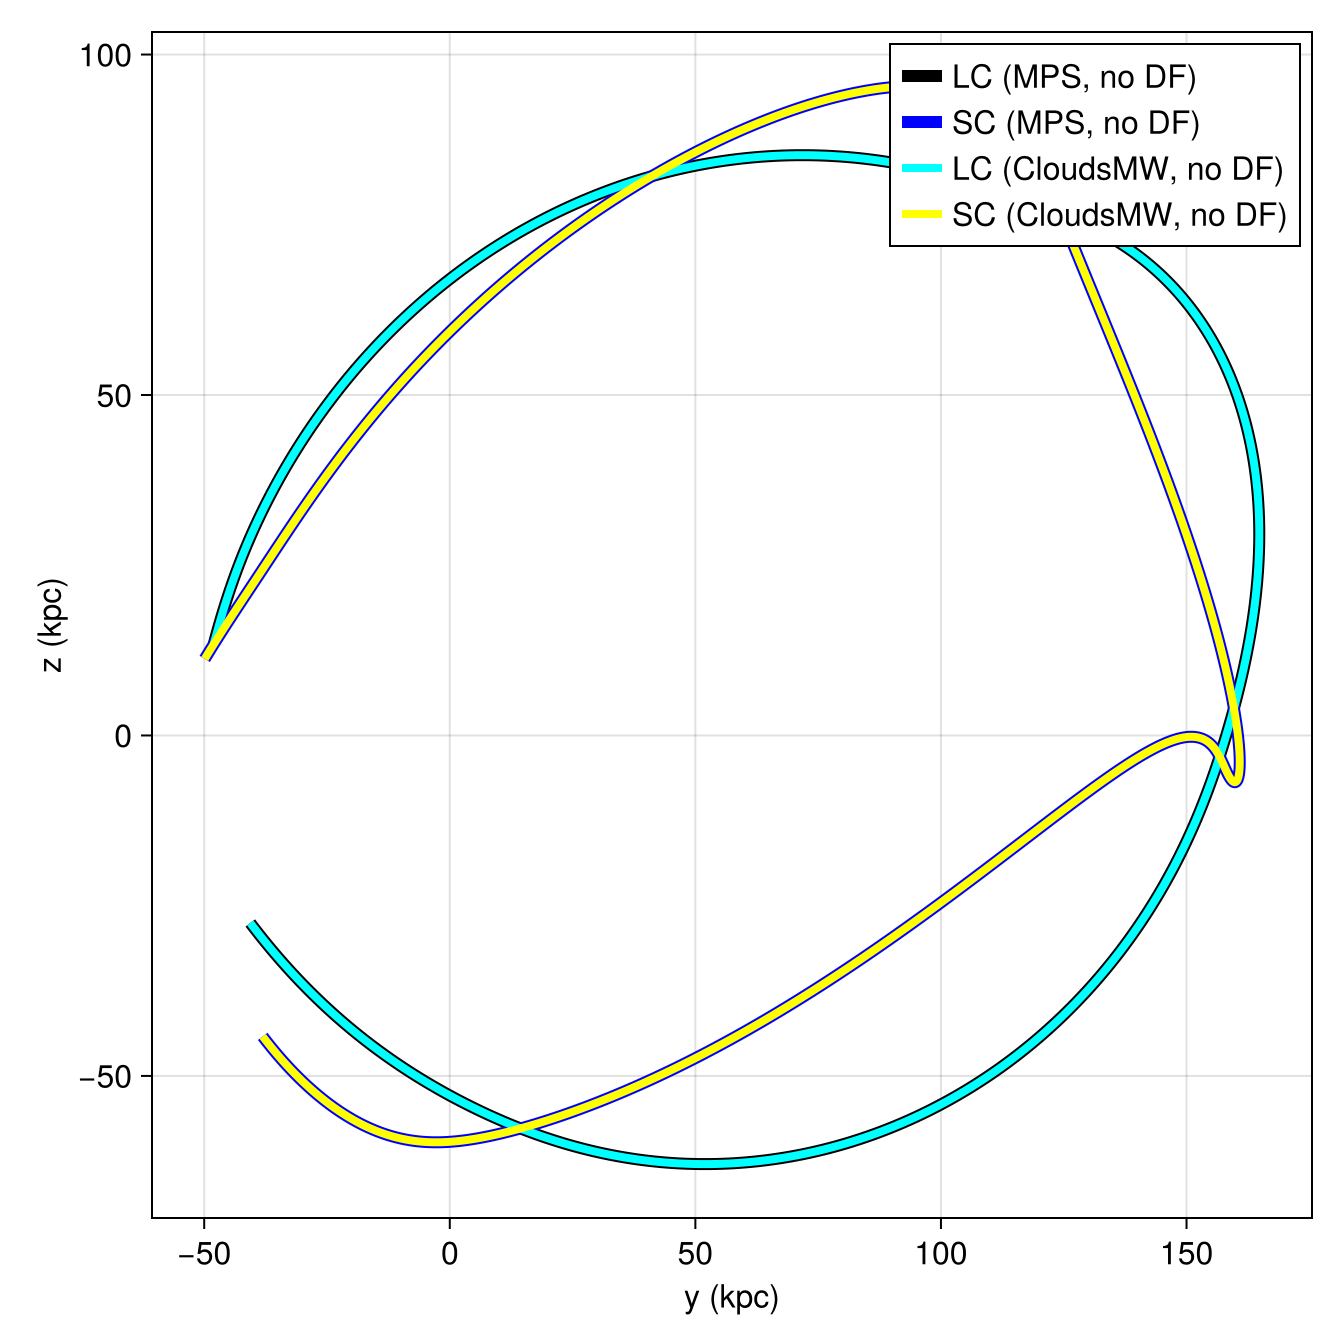

In [138]:
inch = 96
pt = 4/3
f = Figure(size = (7inch, 7inch), fontsize = 12pt)
axis = Axis(f[1,1], xlabel="y (kpc)",  ylabel="z (kpc)")
lines!(axis, x_lc[2,:], x_lc[3,:], color=:black, linewidth=6, label = "LC (MPS, no DF)")
lines!(axis, x_sc[2,:], x_sc[3,:], color=:blue, linewidth=6, label = "SC (MPS, no DF)")
lines!(axis, x_lc_2[2,:], x_lc_2[3,:], color=:cyan, linewidth=4, label = "LC (CloudsMW, no DF)")
lines!(axis, x_sc_2[2,:], x_sc_2[3,:], color=:yellow, linewidth=4, label = "SC (CloudsMW, no DF)")
# lines!(axis, x_lc_f[2,:], x_lc_f[3,:], color=:orange, linewidth=3, label = "LC (MPS, DF)")
# lines!(axis, x_sc_f[2,:], x_sc_f[3,:], color=:green, linewidth=3, label = "SC (MPS, DF)")
# lines!(axis, x_lc_f2[2,:], x_lc_f2[3,:], color=:brown, linewidth=1.5, label = "LC (CloudsMW, DF)")
# lines!(axis, x_sc_f2[2,:], x_sc_f2[3,:], color=:red, linewidth=1.5, label = "SC (CloudsMW, DF)")
axislegend(axis, position=:rt)
# xlims!(axis, -120,120)
# ylims!(axis, -120,120)
save("CloudsMW_nofric_comparison.png", f, px_per_unit=3)
f

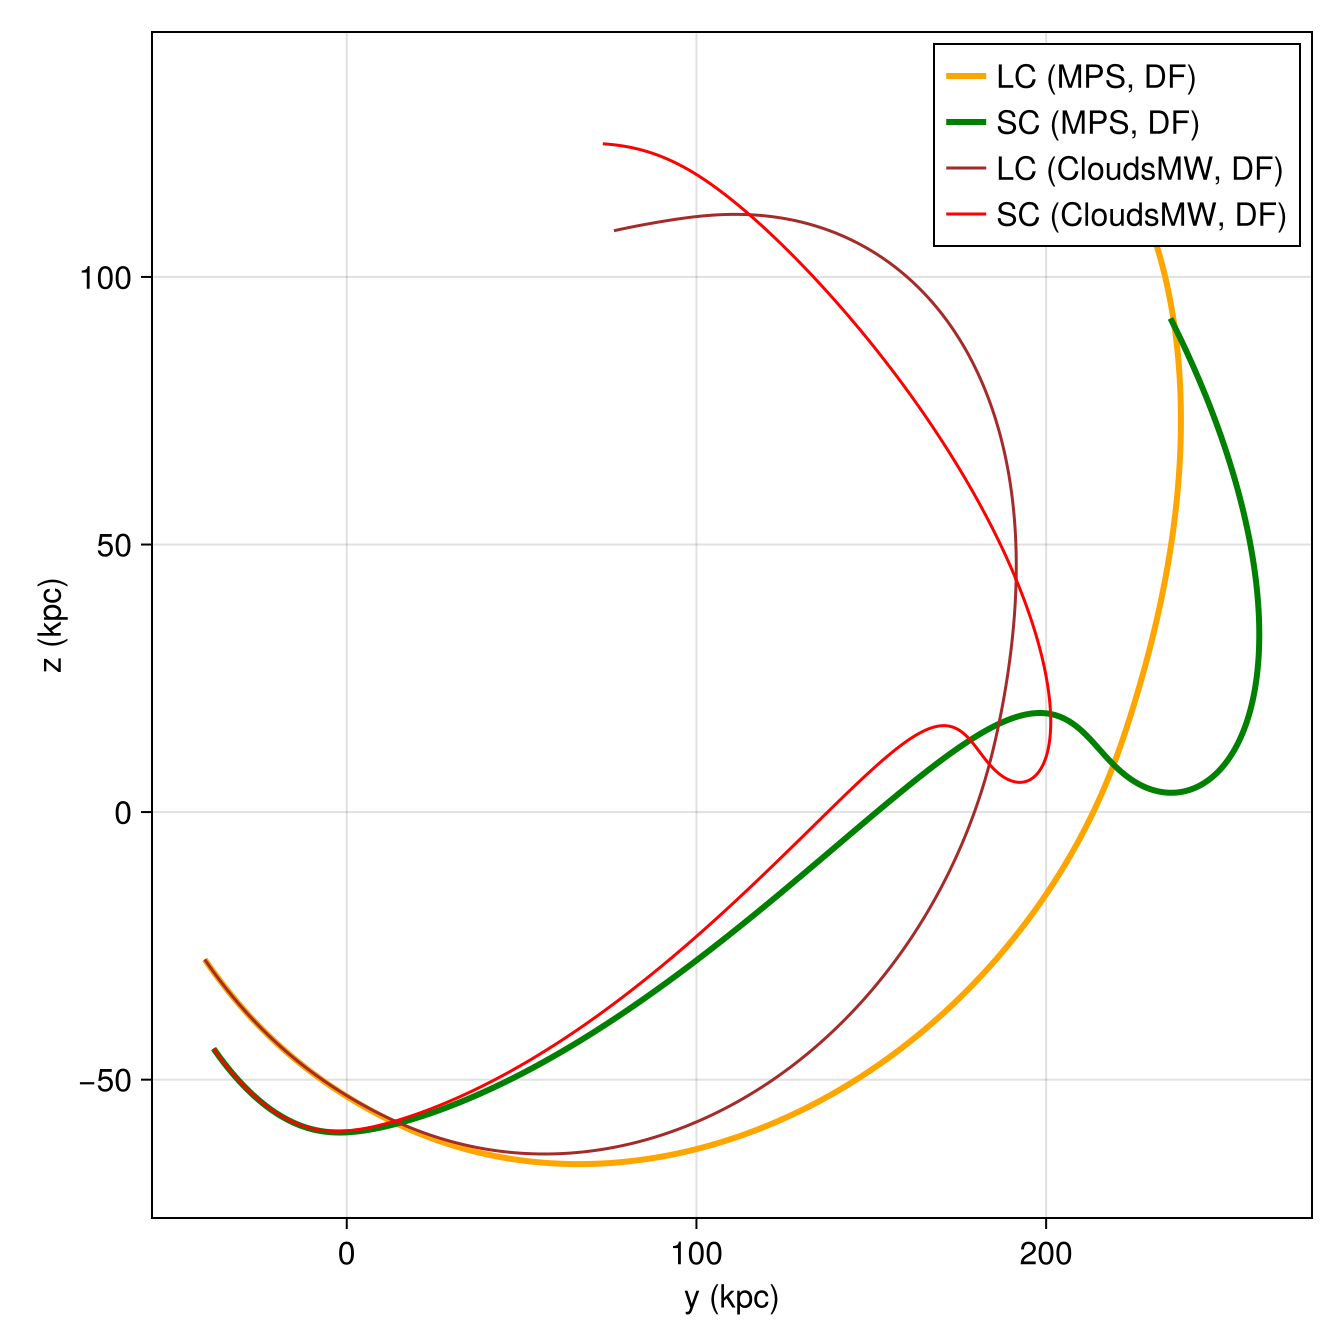

In [139]:
inch = 96
pt = 4/3
f = Figure(size = (7inch, 7inch), fontsize = 12pt)
axis = Axis(f[1,1], xlabel="y (kpc)",  ylabel="z (kpc)")
# lines!(axis, x_lc[2,:], x_lc[3,:], color=:black, linewidth=6, label = "LC (MPS, no DF)")
# lines!(axis, x_sc[2,:], x_sc[3,:], color=:blue, linewidth=6, label = "SC (MPS, no DF)")
# lines!(axis, x_lc_2[2,:], x_lc_2[3,:], color=:cyan, linewidth=4, label = "LC (CloudsMW, no DF)")
# lines!(axis, x_sc_2[2,:], x_sc_2[3,:], color=:yellow, linewidth=4, label = "SC (CloudsMW, no DF)")
lines!(axis, x_lc_f[2,:], x_lc_f[3,:], color=:orange, linewidth=3, label = "LC (MPS, DF)")
lines!(axis, x_sc_f[2,:], x_sc_f[3,:], color=:green, linewidth=3, label = "SC (MPS, DF)")
lines!(axis, x_lc_f2[2,:], x_lc_f2[3,:], color=:brown, linewidth=1.5, label = "LC (CloudsMW, DF)")
lines!(axis, x_sc_f2[2,:], x_sc_f2[3,:], color=:red, linewidth=1.5, label = "SC (CloudsMW, DF)")
axislegend(axis, position=:rt)
# xlims!(axis, -120,120)
# ylims!(axis, -120,120)
save("CloudsMW_withfric_comparison.png", f, px_per_unit=3)
f

Adding friction onto the MW produced by the LC.

In [ ]:
fric = (build_friction(cloudsMW.mw, cloudsMW.large, GalpyFriction),
        build_friction(cloudsMW.mw, cloudsMW.small, GalpyFriction),
        build_friction(cloudsMW.large, cloudsMW.small, GalpyFriction),
        build_friction(cloudsMW.large, cloudsMW.mw, GalpyFriction))
sol_f₃ = evolve(fric, cloudsMW, t_range, Vern7(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))
x_lc_f3 = sol_f₃[2].x - sol_f₃[1].x
x_sc_f3 = sol_f₃[3].x - sol_f₃[1].x

r_min = 0.007000000000000001
r_max = 781.0
scale = 10.3264466
mass = 8.78206139e10
algorithm = GalpyFriction


┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:133
┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:133


r_min = 0.007000000000000001
r_max = 781.0
scale = 8.26115728
mass = 1.22160828e10
algorithm = GalpyFriction
r_min = 1.03264466
r_max = 516.3223300000001
scale = 8.26115728
mass = 1.22160828e10
algorithm = GalpyFriction


┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:133
┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:133


r_min = 1.03264466
r_max = 516.3223300000001
scale = 15.62
mass = 6.1471e11
algorithm = GalpyFriction
🎲 Evolving a CloudsMW system with some of the frictions


3×3001 Matrix{Float64}:
  15.0991   15.0798   15.0602  …   -0.962727   -0.834481   -0.706236
 -38.0888  -37.9006  -37.7118     180.003     179.865     179.726
 -44.1959  -44.3734  -44.5502     138.163     138.253     138.342

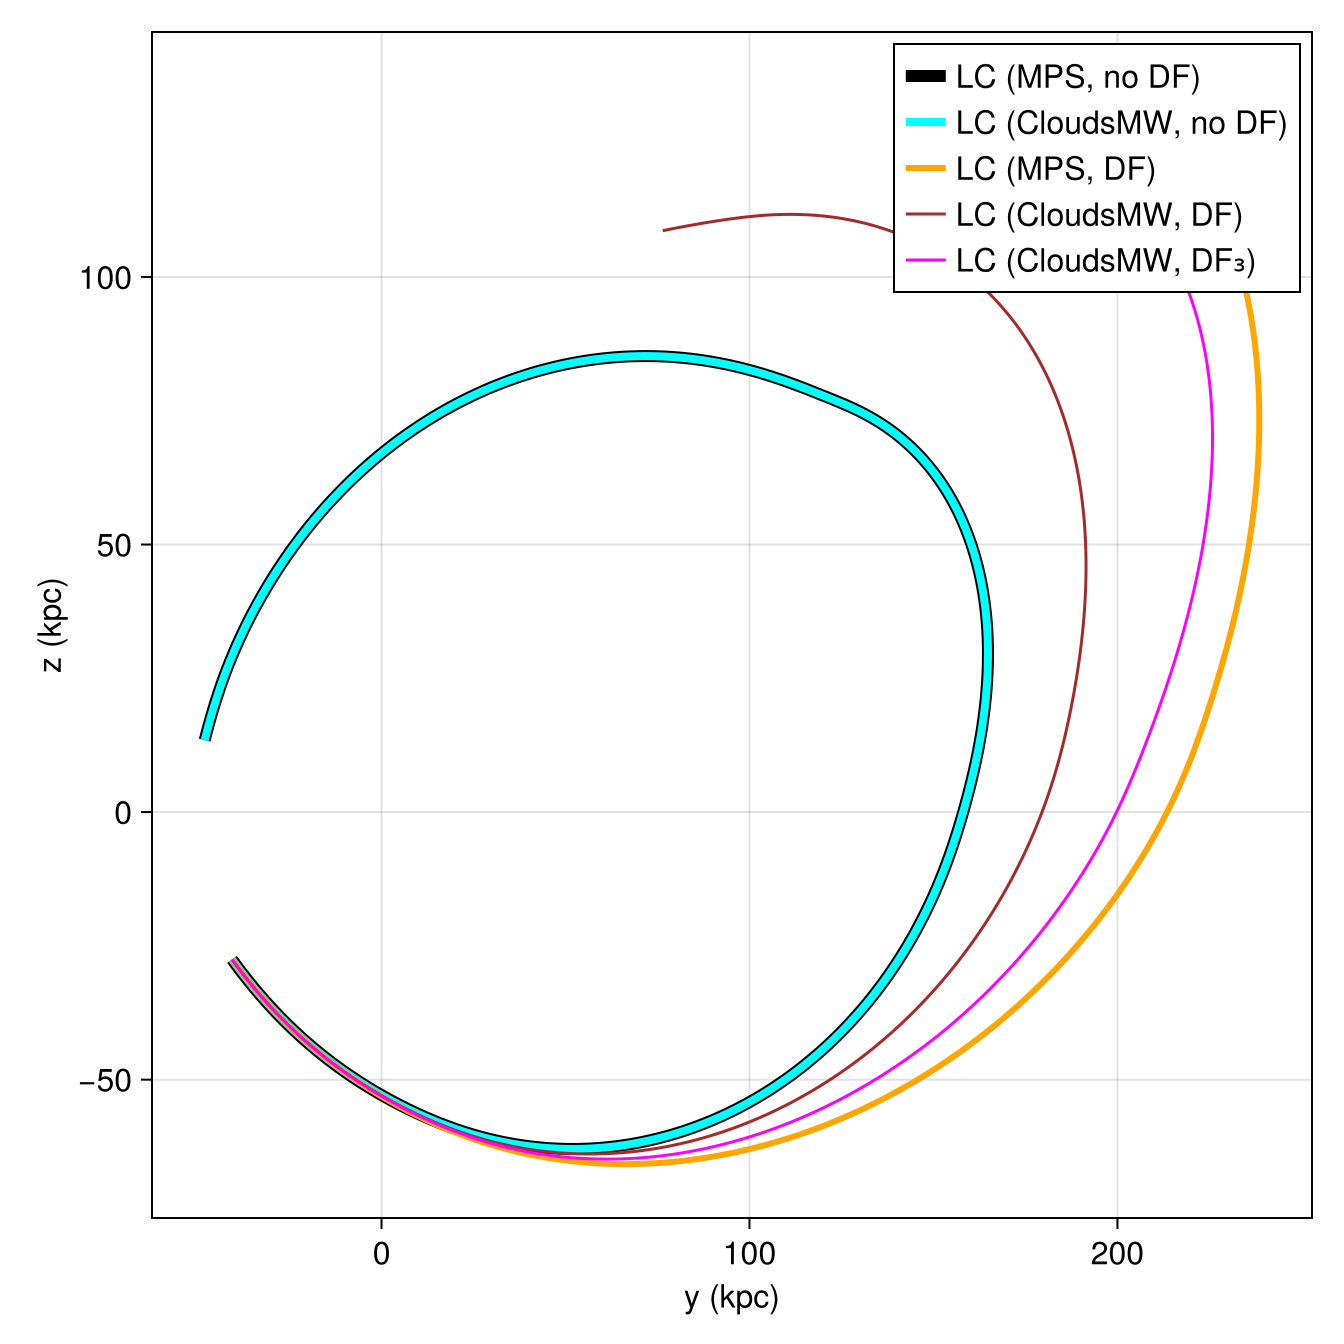

In [143]:
inch = 96
pt = 4/3
f = Figure(size = (7inch, 7inch), fontsize = 12pt)
axis = Axis(f[1,1], xlabel="y (kpc)",  ylabel="z (kpc)")
lines!(axis, x_lc[2,:], x_lc[3,:], color=:black, linewidth=6, label = "LC (MPS, no DF)")
# lines!(axis, x_sc[2,:], x_sc[3,:], color=:blue, linewidth=6, label = "SC (MPS, no DF)")
lines!(axis, x_lc_2[2,:], x_lc_2[3,:], color=:cyan, linewidth=4, label = "LC (CloudsMW, no DF)")
# lines!(axis, x_sc_2[2,:], x_sc_2[3,:], color=:yellow, linewidth=4, label = "SC (CloudsMW, no DF)")
lines!(axis, x_lc_f[2,:], x_lc_f[3,:], color=:orange, linewidth=3, label = "LC (MPS, DF)")
# lines!(axis, x_sc_f[2,:], x_sc_f[3,:], color=:green, linewidth=3, label = "SC (MPS, DF)")
lines!(axis, x_lc_f2[2,:], x_lc_f2[3,:], color=:brown, linewidth=1.5, label = "LC (CloudsMW, DF)")
# lines!(axis, x_sc_f2[2,:], x_sc_f2[3,:], color=:red, linewidth=1.5, label = "SC (CloudsMW, DF)")
lines!(axis, x_lc_f3[2,:], x_lc_f3[3,:], color=:magenta, linewidth=1.5, label = "LC (CloudsMW, DF₃)")

axislegend(axis, position=:rt)
# xlims!(axis, -120,120)
# ylims!(axis, -120,120)
save("CloudsMW_withfric_comparison.png", f, px_per_unit=3)
f

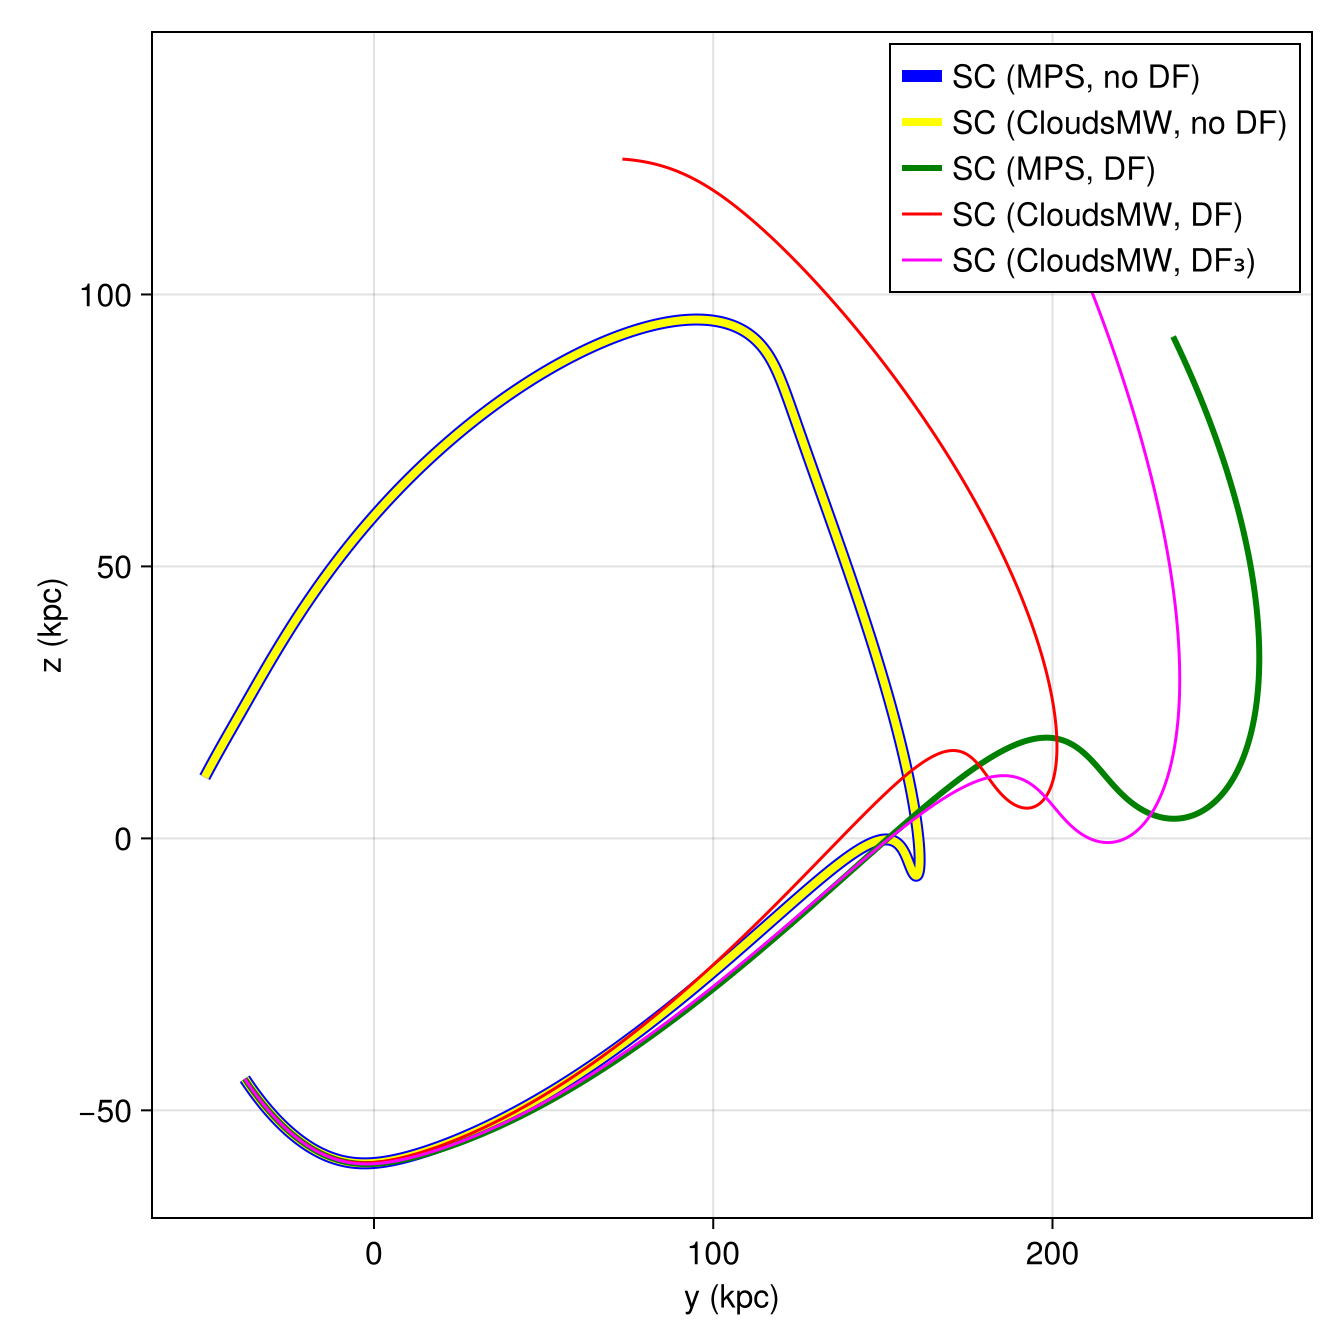

In [145]:
inch = 96
pt = 4/3
f = Figure(size = (7inch, 7inch), fontsize = 12pt)
axis = Axis(f[1,1], xlabel="y (kpc)",  ylabel="z (kpc)")
# lines!(axis, x_lc[2,:], x_lc[3,:], color=:black, linewidth=6, label = "LC (MPS, no DF)")
lines!(axis, x_sc[2,:], x_sc[3,:], color=:blue, linewidth=6, label = "SC (MPS, no DF)")
# lines!(axis, x_lc_2[2,:], x_lc_2[3,:], color=:cyan, linewidth=4, label = "LC (CloudsMW, no DF)")
lines!(axis, x_sc_2[2,:], x_sc_2[3,:], color=:yellow, linewidth=4, label = "SC (CloudsMW, no DF)")
# lines!(axis, x_lc_f[2,:], x_lc_f[3,:], color=:orange, linewidth=3, label = "LC (MPS, DF)")
lines!(axis, x_sc_f[2,:], x_sc_f[3,:], color=:green, linewidth=3, label = "SC (MPS, DF)")
# lines!(axis, x_lc_f2[2,:], x_lc_f2[3,:], color=:brown, linewidth=1.5, label = "LC (CloudsMW, DF)")
lines!(axis, x_sc_f2[2,:], x_sc_f2[3,:], color=:red, linewidth=1.5, label = "SC (CloudsMW, DF)")
# lines!(axis, x_lc_f3[2,:], x_lc_f3[3,:], color=:magenta, linewidth=1.5, label = "LC (CloudsMW, DF₃)")
lines!(axis, x_sc_f3[2,:], x_sc_f3[3,:], color=:magenta, linewidth=1.5, label = "SC (CloudsMW, DF₃)")
axislegend(axis, position=:rt)
# xlims!(axis, -120,120)
# ylims!(axis, -120,120)
save("CloudsMW_withfric_comparison.png", f, px_per_unit=3)
f

### Testing dynamical friction with Daniel data from real N-body simulations

Now I compare with N-body simulations from Daniel Carpintero from present time until 3Gyr in the future, using the following parameters and initial conditions:

* [m]=1 M_sun, [l]=1 kpc, [v]=1 km/s: G=4.30209e-6, [t]=0.97779 Gy

x,v MW

0.035362129 -0.047567887 0.12563366 3.2444904 4.946024 -4.1400647

x,v LMC

-1.0608514 -41.039118 -27.301268 -45.043434 -215.20296 199.05423

x,v SMC

15.429289 -37.213295 -43.296201 29.240969 -176.34462 155.23363

* MW (NFW)
rho0=1.96266e7
a=12.6829
r200=202.926
m200=9.52e11

* LMC (NFW)
rho0=4.71209e6
a=12.9412
r200=116.47
m200=1.8e11

* SMC (NFW)
rho0=2.28895e7
a=2.47345
r200=42.0487
m200=8.47e9

In [ ]:
t₁ = 0.0
t₂ = 3.0
t_range = (t₁, t₂)
Δt = 0.001
pot_mw = NFW_from_mv_a(9.52e11, 12.6829)
pot_large = NFW_from_mv_a(1.8e11, 12.9412)
pot_small = NFW_from_mv_a(8.47e9, 2.47345)
x_mw = [0.035362129, -0.047567887, 0.12563366]
v_mw = adimensional([3.2444904, 4.946024, -4.1400647]*𝕦.ν)
x_large = [-1.0608514, -41.039118, -27.301268]
v_large = adimensional([-45.043434, -215.20296, 199.05423]*𝕦.ν)
x_small = [15.429289, -37.213295, -43.296201]
v_small = adimensional([29.240969, -176.34462, 155.23363]*𝕦.ν)
mp_mw = MacroParticle(pot_mw, x_mw, v_mw)
mp_large = MacroParticle(pot_large, x_large, v_large)
mp_small = MacroParticle(pot_small, x_small, v_small)
mps = MacroParticleSystem(mp_mw, mp_large, mp_small)

sol_nb = evolve(mps, t_range, Vern9(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))
x_lc_nb = sol_nb[2].x - sol_nb[1].x
x_sc_nb = sol_nb[3].x - sol_nb[1].x

cloudsMW = CloudsMW(mps)
fric = (build_friction(cloudsMW.mw, cloudsMW.large, GalpyFriction), build_friction(cloudsMW.mw, cloudsMW.small, GalpyFriction), build_friction(cloudsMW.large, cloudsMW.small, GalpyFriction) )
sol_nb2 = evolve(fric, cloudsMW, t_range, Vern9(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))
x_lc_nb2 = sol_nb2[2].x - sol_nb2[1].x
x_sc_nb2 = sol_nb2[3].x - sol_nb2[1].x

df = DataFrame(x_lc = x_lc_nb[1,:], y_lc=x_lc_nb[2,:], z_lc=x_lc_nb[3,:],
                x_sc = x_sc_nb[1,:], y_sc=x_sc_nb[2,:], z_sc=x_sc_nb[3,:],
                x_mw = sol_nb[1].x[1,:], y_mw = sol_nb[1].x[2,:], z_mw=sol_nb[1].x[3,:])
CSV.write("clouds_full_frictions_Daniel_data.csv",df)

df = DataFrame(x_lc = x_lc_nb2[1,:], y_lc=x_lc_nb2[2,:], z_lc=x_lc_nb2[3,:],
                x_sc = x_sc_nb2[1,:], y_sc=x_sc_nb2[2,:], z_sc=x_sc_nb2[3,:],
                x_mw = sol_nb2[1].x[1,:], y_mw = sol_nb2[1].x[2,:], z_mw=sol_nb2[1].x[3,:])
CSV.write("clouds_partial_frictions_Daniel_data.csv",df)

🎲 Evolving a MPS system without friction, GenSystTrait
r_min = 1.2682900000000001
r_max = 634.145
scale = 12.9412
mass = 1.2667331932956609e11
algorithm = GalpyFriction
r_min = 1.2682900000000001
r_max = 634.145
scale = 2.47345
mass = 4.307877555571918e9
algorithm = GalpyFriction


┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:133
┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:133
┌ Warning: The value of α is not exact for general potentials
└ @ Dynamigal /mnt/md2/mmestre/work/Packages/Dynamigal/src/dissipative/drags.jl:133


r_min = 1.2941200000000002
r_max = 647.0600000000001
scale = 2.47345
mass = 4.307877555571918e9
algorithm = GalpyFriction
🎲 Evolving a CloudsMW system with some of the frictions


"clouds_partial_frictions_Daniel_data.csv"

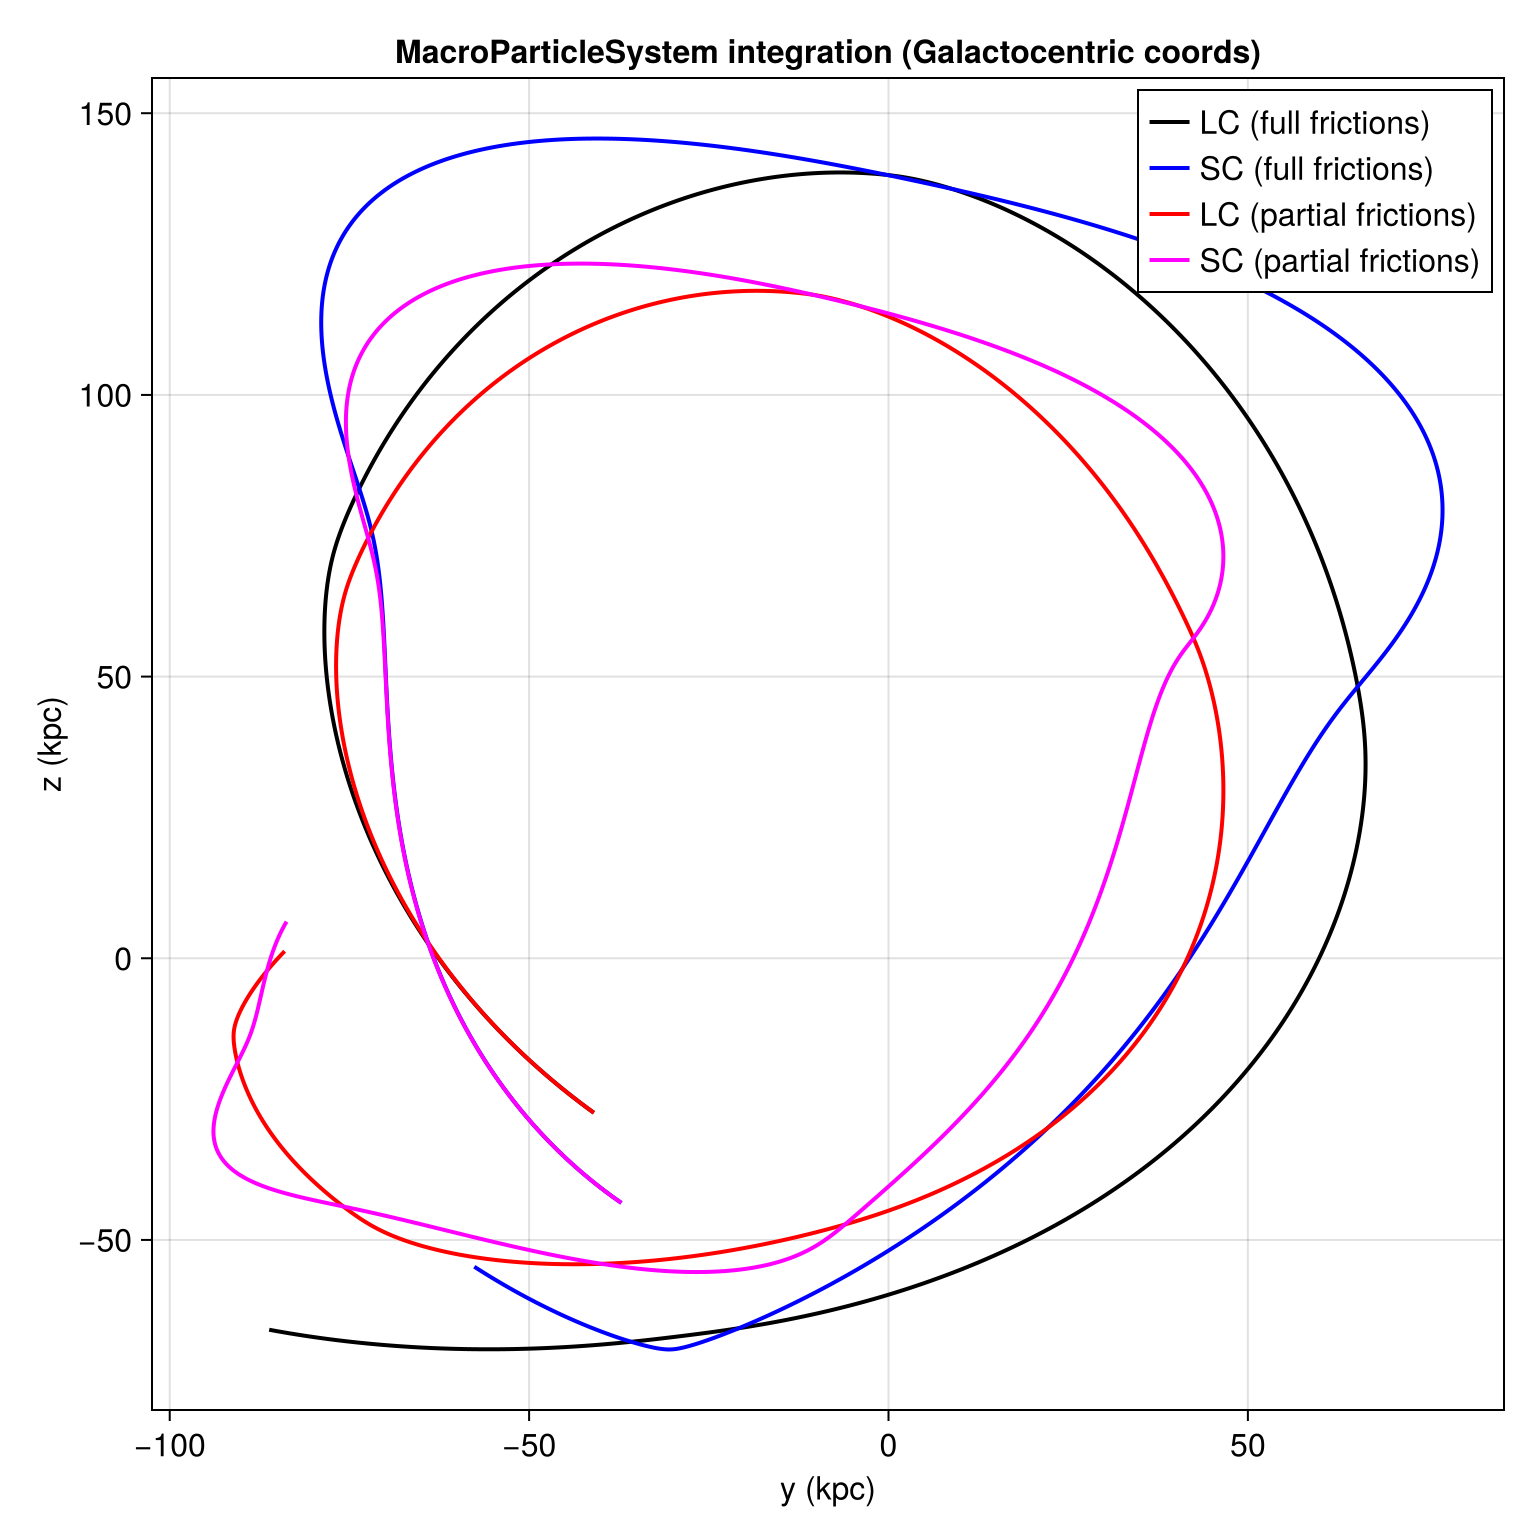

In [193]:
inch = 96
pt = 4/3
f = Figure(size = (8inch, 8inch), fontsize = 12pt)
axis = Axis(f[1,1], xlabel="y (kpc)",  ylabel="z (kpc)", title="MacroParticleSystem integration (Galactocentric coords)")
lines!(axis, x_lc_nb[2,:], x_lc_nb[3,:], color=:black, linewidth=2, label = "LC (full frictions)")
lines!(axis, x_sc_nb[2,:], x_sc_nb[3,:], color=:blue, linewidth=2, label = "SC (full frictions)")
lines!(axis, x_lc_nb2[2,:], x_lc_nb2[3,:], color=:red, linewidth=2, label = "LC (partial frictions)")
lines!(axis, x_sc_nb2[2,:], x_sc_nb2[3,:], color=:magenta, linewidth=2, label = "SC (partial frictions)")

axislegend(axis, position=:rt)
# xlims!(axis, -120,120)
# ylims!(axis, -120,120)
save("CloudsMW_orbits_with_Daniel_data_yz.png", f, px_per_unit=3)
f

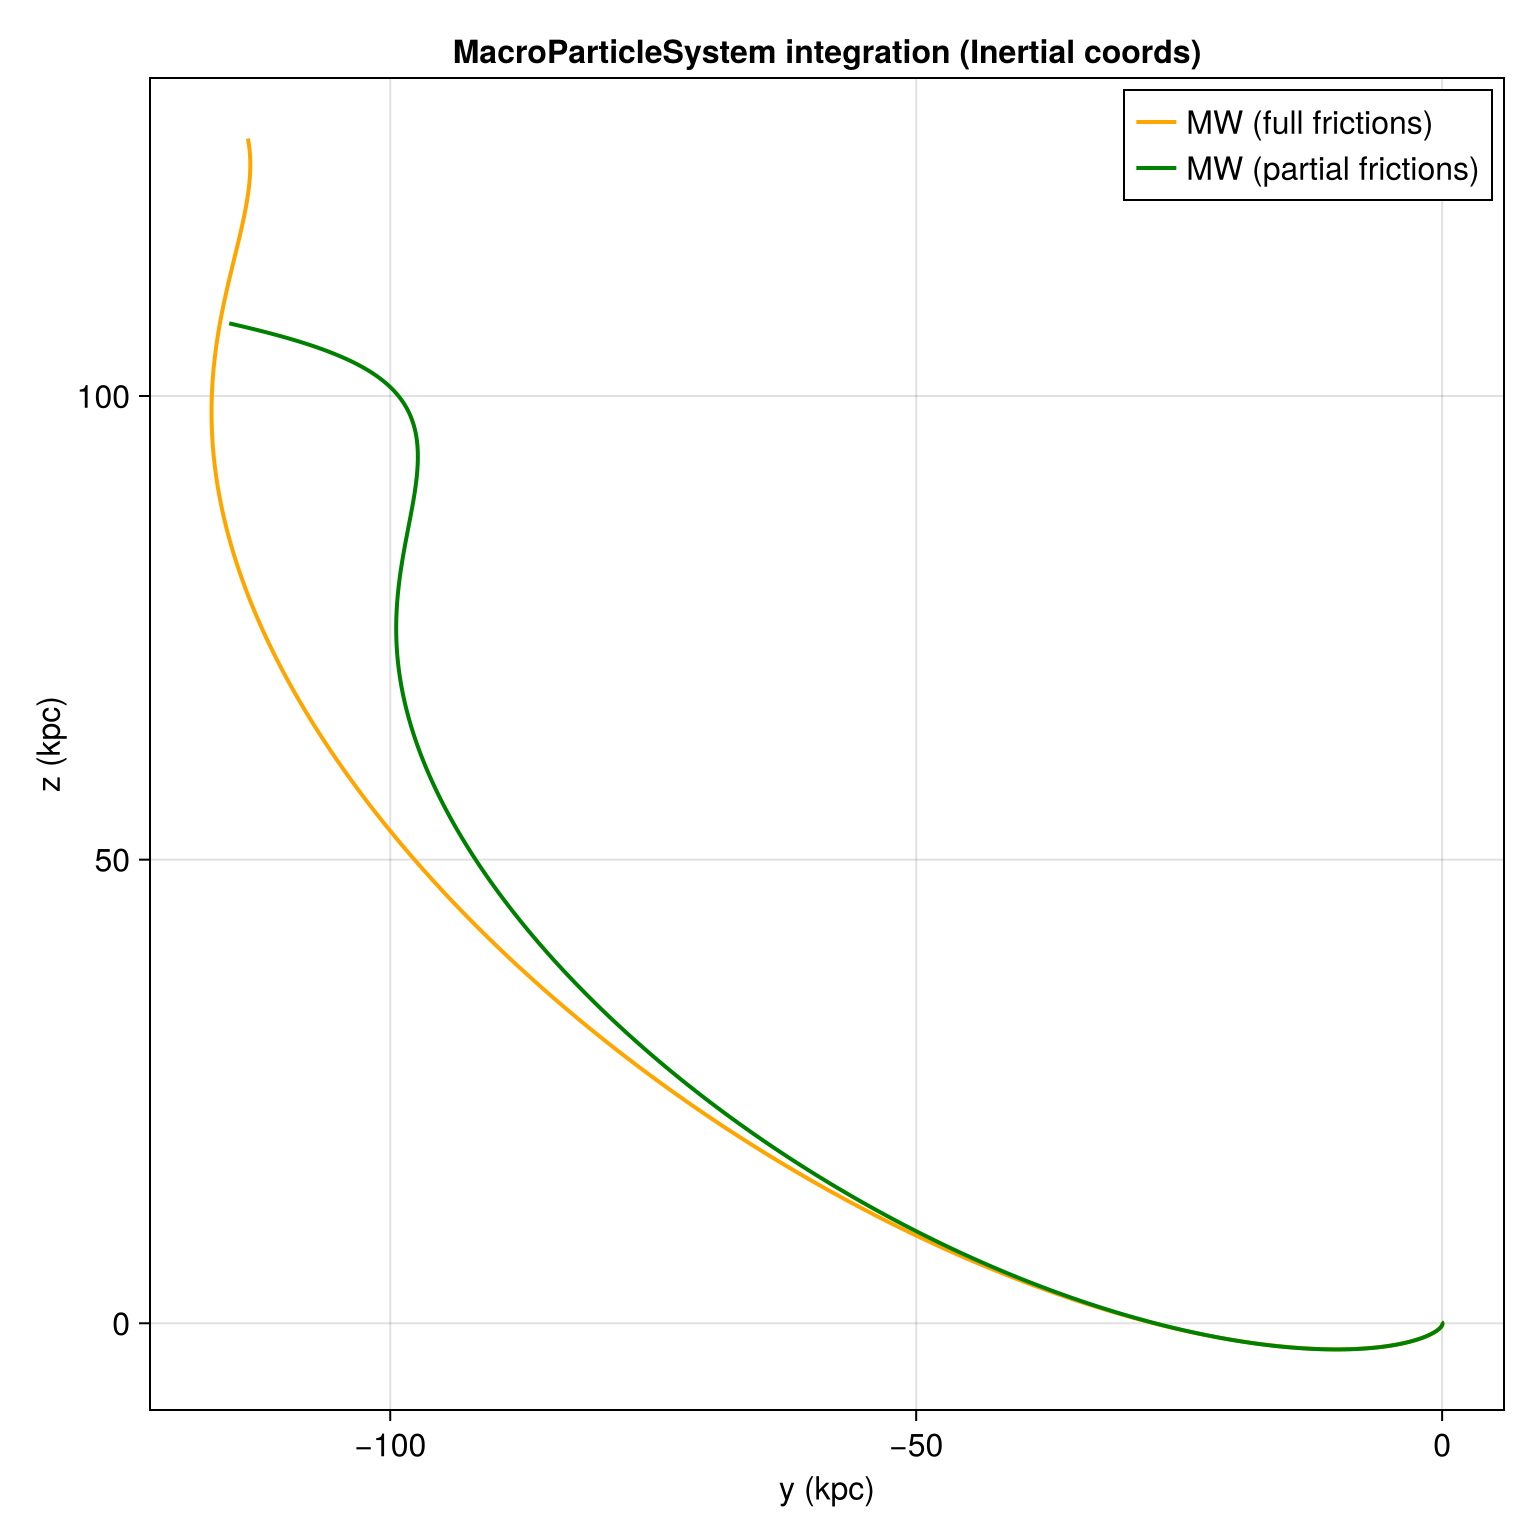

In [194]:
inch = 96
pt = 4/3
f = Figure(size = (8inch, 8inch), fontsize = 12pt)
axis = Axis(f[1,1], xlabel="y (kpc)",  ylabel="z (kpc)", title="MacroParticleSystem integration (Inertial coords)")
lines!(axis, sol_nb[1].x[2,:], sol_nb[1].x[3,:], color=:orange, linewidth=2, label = "MW (full frictions)")
lines!(axis, sol_nb2[1].x[2,:], sol_nb2[1].x[3,:], color=:green, linewidth=2, label = "MW (partial frictions)")

axislegend(axis, position=:rt)
# xlims!(axis, -120,120)
# ylims!(axis, -120,120)
# save("MW_orbit_in_inertial_frame_with_Daniel_data_yz.png", f, px_per_unit=3)
f

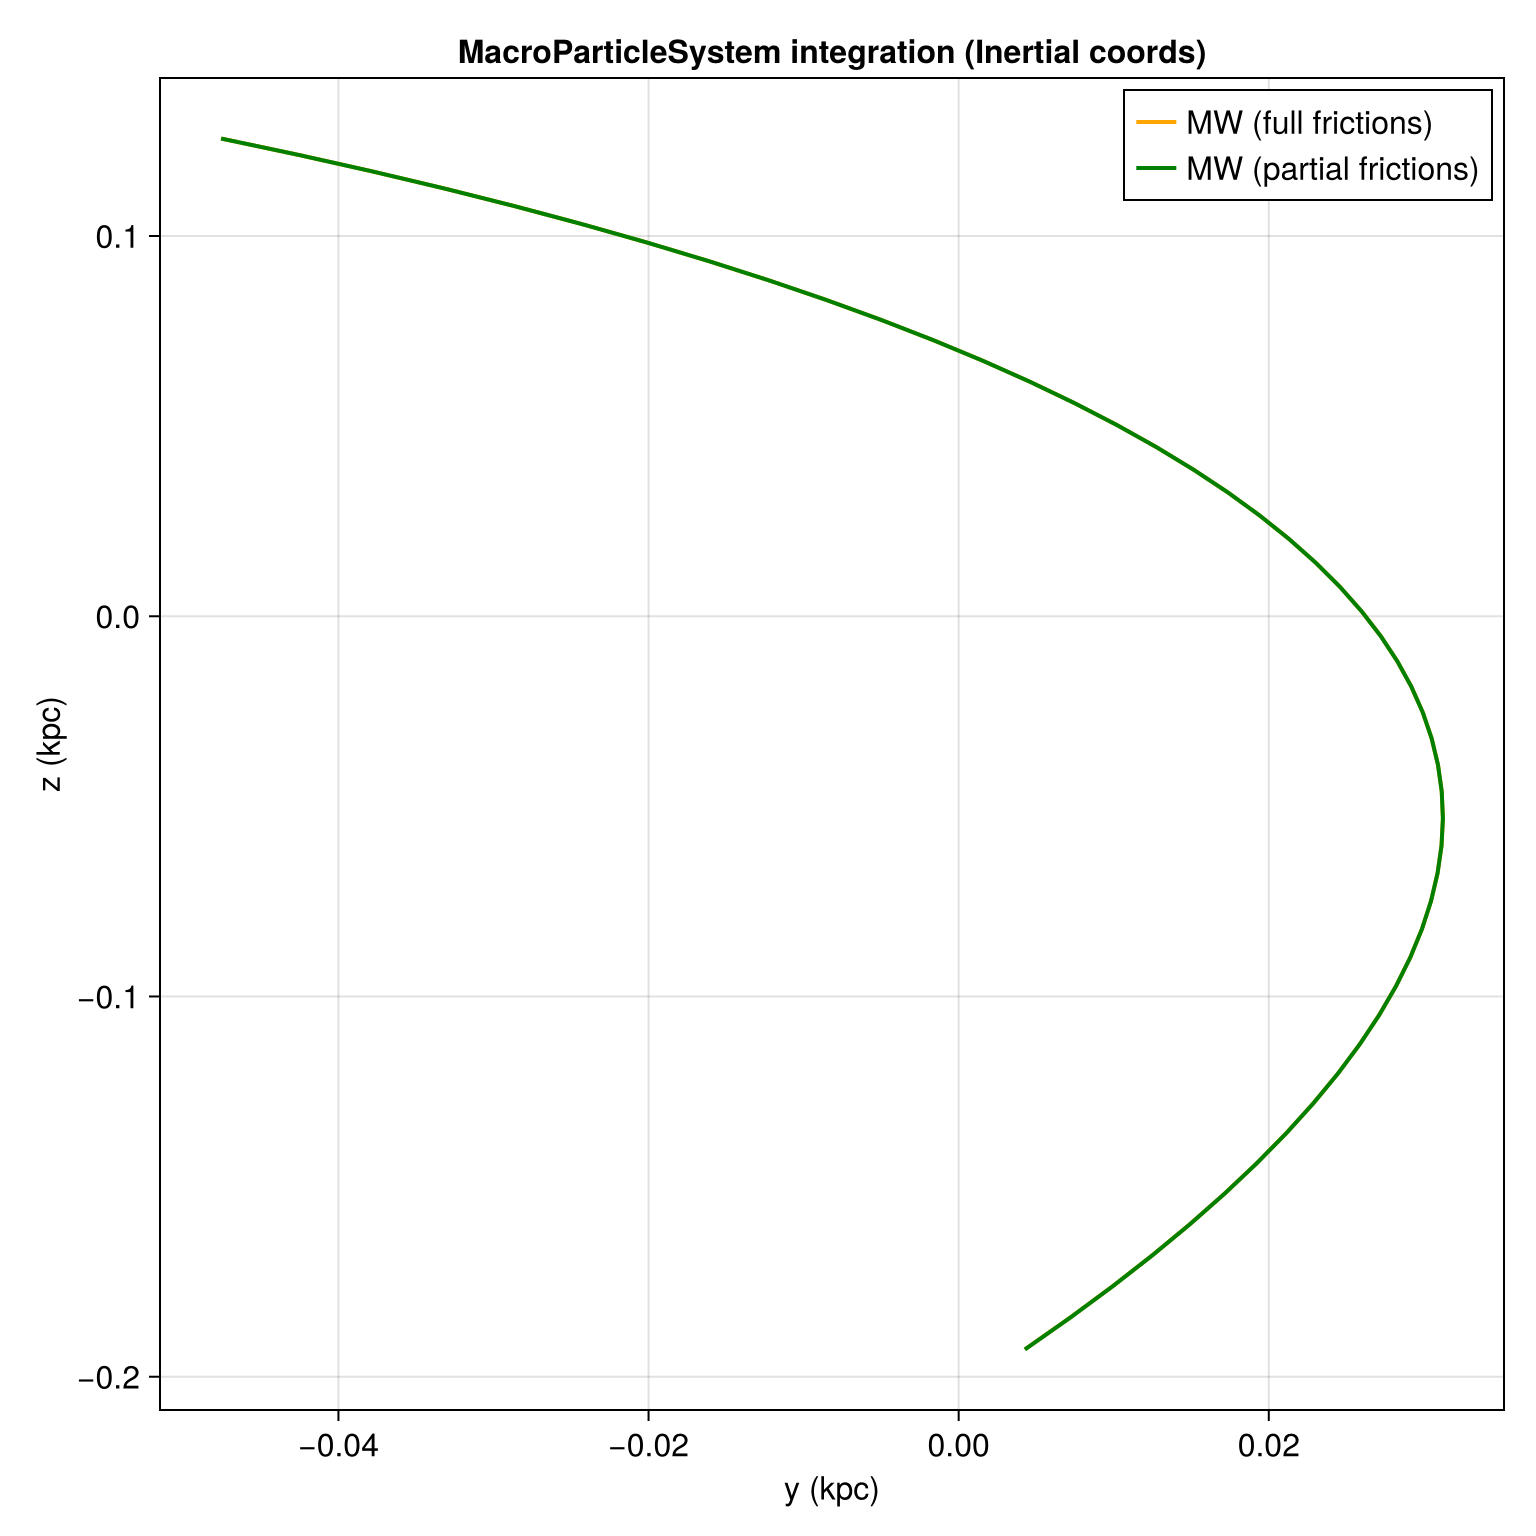

In [187]:
inch = 96
pt = 4/3
f = Figure(size = (8inch, 8inch), fontsize = 12pt)
axis = Axis(f[1,1], xlabel="y (kpc)",  ylabel="z (kpc)", title="MacroParticleSystem integration (Inertial coords)")
lines!(axis, sol_nb[1].x[2,1:50], sol_nb[1].x[3,1:50], color=:orange, linewidth=2, label = "MW (full frictions)")
lines!(axis, sol_nb2[1].x[2,1:50], sol_nb2[1].x[3,1:50], color=:green, linewidth=2, label = "MW (partial frictions)")

axislegend(axis, position=:rt)
# xlims!(axis, -120,120)
# ylims!(axis, -120,120)
# save("MW_orbit_in_inertial_frame_with_Daniel_data_yz.png", f, px_per_unit=3)
f

🎲 Evolving a MPS system without friction, GenSystTrait
🎲 Evolving a CloudsMW system with some of the frictions
🎲 Evolving a MPS system without friction, GenSystTrait
🎲 Evolving a CloudsMW system with some of the frictions


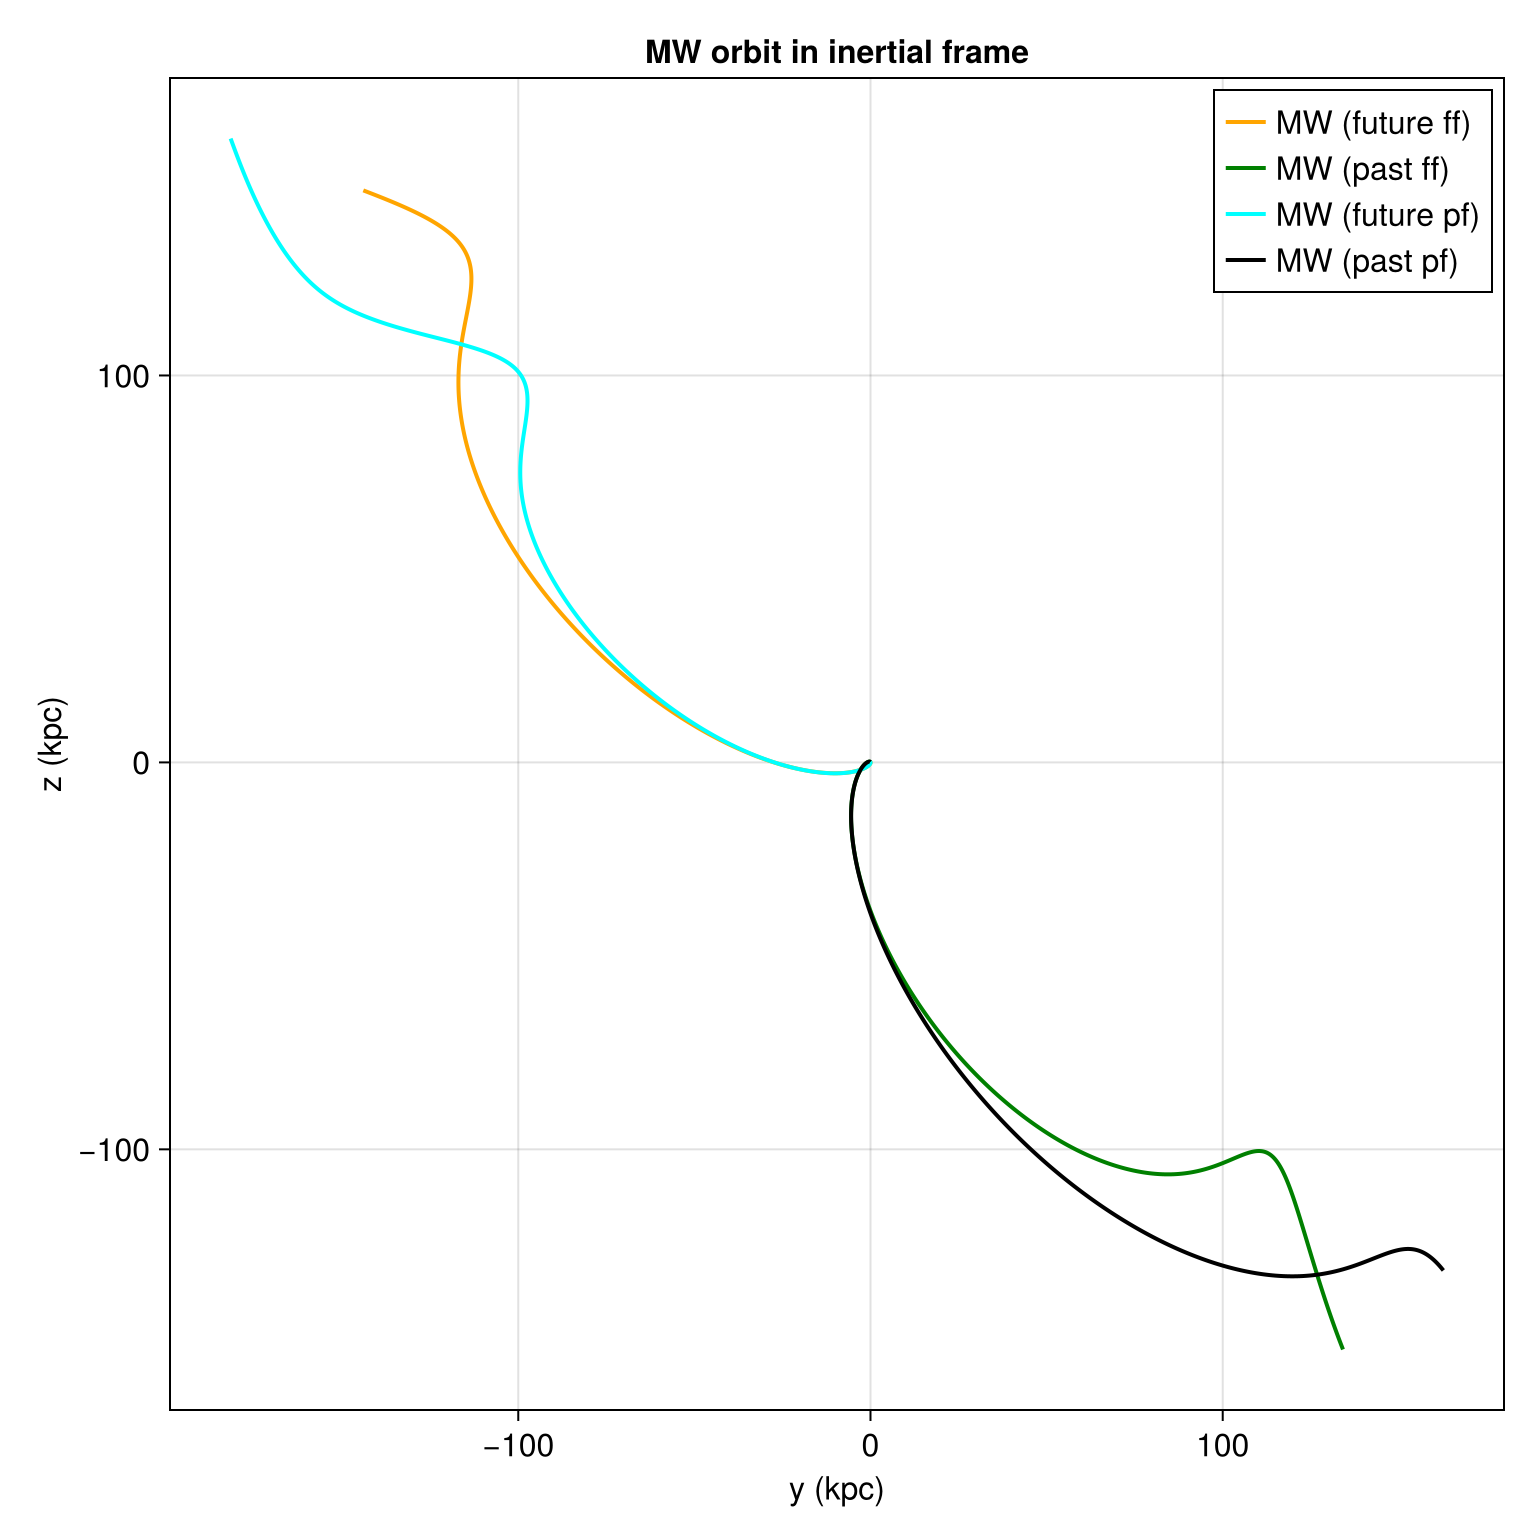

In [208]:
t₁ = 0.0
t₂ = 4.0
t_range = (t₁, t₂)
Δt = 0.001
pot_mw = NFW_from_mv_a(9.52e11, 12.6829)
pot_large = NFW_from_mv_a(1.8e11, 12.9412)
pot_small = NFW_from_mv_a(8.47e9, 2.47345)
x_mw = [0.035362129, -0.047567887, 0.12563366]
v_mw = adimensional([3.2444904, 4.946024, -4.1400647]*𝕦.ν)
x_large = [-1.0608514, -41.039118, -27.301268]
v_large = adimensional([-45.043434, -215.20296, 199.05423]*𝕦.ν)
x_small = [15.429289, -37.213295, -43.296201]
v_small = adimensional([29.240969, -176.34462, 155.23363]*𝕦.ν)
mp_mw = MacroParticle(pot_mw, x_mw, v_mw)
mp_large = MacroParticle(pot_large, x_large, v_large)
mp_small = MacroParticle(pot_small, x_small, v_small)
mps = MacroParticleSystem(mp_mw, mp_large, mp_small)
cloudsMW = CloudsMW(mps)

sol_fut = evolve(mps, t_range, Vern9(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))
sol_fut2 = evolve(fric, cloudsMW, t_range, Vern9(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))

t₁ = 0.0
t₂ = -4.0
t_range = (t₁, t₂)
Δt = -0.001

sol_pas = evolve(mps, t_range, Vern9(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))
sol_pas2 = evolve(fric, cloudsMW, t_range, Vern9(); options=ntSolverOptions(; reltol=5.0e-14, abstol=0.5e-14,saveat=Δt))

inch = 96
pt = 4/3
f = Figure(size = (8inch, 8inch), fontsize = 12pt)
axis = Axis(f[1,1], xlabel="y (kpc)",  ylabel="z (kpc)", title="MW orbit in inertial frame")
lines!(axis, sol_fut[1].x[2,:], sol_fut[1].x[3,:], color=:orange, linewidth=2, label = "MW (future ff)")
lines!(axis, sol_pas[1].x[2,:], sol_pas[1].x[3,:], color=:green, linewidth=2, label = "MW (past ff)")
lines!(axis, sol_fut2[1].x[2,:], sol_fut2[1].x[3,:], color=:cyan, linewidth=2, label = "MW (future pf)")
lines!(axis, sol_pas2[1].x[2,:], sol_pas2[1].x[3,:], color=:black, linewidth=2, label = "MW (past pf)")
axislegend(axis, position=:rt)
f